# Session 1: Multiple Linear Regression
## Wheat Yield Prediction 
  
**Goal:** Understand our dataset and build your first yield prediction model using Multiple Linear Regression

---

### Session Roadmap
|  | Tasks |
|------|-------|
| Part 1 | Loading & first look at the data |
| Part 2 | Exploratory Data Analysis (EDA) |
| Part 3 | Multiple Linear Regression |
| Part 4 | Model evaluation & limitations |
| Part 5 | Wrap-up & questions |

---

In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')




---
## Part 1: Dataset

The dataset contains **multiscale features** for wheat growing across Western Australia (WA), spanning 1989–2021.  
Each row represents one **grid cell × one year** combination. Please refer to `README.md` for data description. 

### Question 1.1 — What is in this dataset?
Before loading, think about:
- What kind of variables do you expect to influence wheat yield?


In [2]:
# Load the data
DATA_PATH = 'data/wheat_features.parquet'  

df = pd.read_parquet(DATA_PATH)
print('=== First 5 rows ===')
df.head()

=== First 5 rows ===


,lat,lon,year,wheat_yield,sowing_doy,no_sow,pawc_0_30_mm,pawc_0_60_mm,ph_0_30,minN_0_30,...,cum_water_stress_W4_grainFill,FASW_at_sowing,FASW_W4_drying_rate,vern_sum_W2_veg,fD_mean_W2_veg,hg_mean_W4,heat_sen_W4,VPD_mean_crop,TE_mean_crop,TT_cum_crop
0,-35.000000,117.099998,1989,3.306941,91.0,0,17.0,37.0,4.6,9.0,...,52.740074,0.089739,0.005097,10.082731,0.568664,0.656226,0.0,6.934572,0.000971,2050.050293
1,-35.000000,117.150002,1989,3.083793,91.0,0,17.0,37.0,4.6,9.0,...,49.540401,0.112083,0.002460,9.837662,0.568664,0.660201,0.0,6.997971,0.000962,2050.949951
2,-34.950001,116.949997,1989,2.841632,91.0,0,17.0,37.0,4.6,9.0,...,50.224014,0.108722,0.002219,10.237930,0.568887,0.652874,0.0,6.927785,0.000969,2053.500244
3,-34.950001,117.000000,1989,2.918803,91.0,0,17.0,37.0,4.6,9.0,...,50.511131,0.110831,0.002641,10.249600,0.568887,0.652203,0.0,6.934721,0.000968,2052.849854
4,-34.950001,117.050003,1989,2.707774,91.0,0,30.0,38.0,4.8,9.0,...,53.367165,0.063888,0.000135,10.377972,0.568887,0.649904,0.0,6.916680,0.000972,2048.149658


In [3]:
print(f'Total columns: {len(df.columns)}')
print('\nAll column names:')
for i, c in enumerate(df.columns):
    print(f'  {i+1:3d}. {c}')

Total columns: 146

All column names:
    1. lat
    2. lon
    3. year
    4. wheat_yield
    5. sowing_doy
    6. no_sow
    7. pawc_0_30_mm
    8. pawc_0_60_mm
    9. ph_0_30
   10. minN_0_30
   11. profile_depth_cm
   12. rain_sum_W1_estab
   13. rain_days_W1_estab
   14. rad_mean_W1_estab
   15. rad_sum_W1_estab
   16. tmean_W1_estab
   17. tmax_max_W1_estab
   18. tmin_min_W1_estab
   19. diurnal_W1_estab
   20. tt_sum_W1_estab
   21. fT_photo_W1_estab
   22. heat_days_W1_estab
   23. frost_days_W1_estab
   24. vpd_mean_W1_estab
   25. fasw_mean_W1_estab
   26. rain_sum_W2_veg
   27. rain_days_W2_veg
   28. rad_mean_W2_veg
   29. rad_sum_W2_veg
   30. tmean_W2_veg
   31. tmax_max_W2_veg
   32. tmin_min_W2_veg
   33. diurnal_W2_veg
   34. tt_sum_W2_veg
   35. fT_photo_W2_veg
   36. heat_days_W2_veg
   37. frost_days_W2_veg
   38. vpd_mean_W2_veg
   39. fasw_mean_W2_veg
   40. rain_sum_W3_preAnth
   41. rain_days_W3_preAnth
   42. rad_mean_W3_preAnth
   43. rad_sum_W3_preAnth
   44

In [4]:

print('Data types:')
print(df.dtypes.value_counts())
print()
df.info()

Data types:
float32    143
int32        1
int8         1
float64      1
Name: count, dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 234696 entries, 0 to 234695
Columns: 146 entries, lat to TT_cum_crop
dtypes: float32(143), float64(1), int32(1), int8(1)
memory usage: 130.9 MB


### Question 1.2 — Column Groups
The columns fall into four groups. Can you identify which columns belong to each group?

| Group | Description | Example columns |
|-------|-------------|------------------|
| **ID / Target** | Location, time, and yield | `lat`, `lon`, `year`, `wheat_yield` |
| **Soil** | Static soil properties | `pawc_0_30_mm`, `ph_0_30`, ... |
| **Crop-seasonal** | Weather during crop growth windows | `rain_sum_W1_estab`, `tmean_W3_preAnth`, ... |
| **Monthly** | Month-by-month rainfall | `rain_sum_mpre6`, `rain_sum_m0`, ... |

**Exercise:** Count how many columns are in each group using the cell below.

In [5]:
# Categorise the columns ───────────────────────────
id_cols   = ['lat', 'lon', 'year', 'wheat_yield', 'sowing_doy', 'no_sow']
soil_cols = ['pawc_0_30_mm', 'pawc_0_60_mm', 'ph_0_30', 'minN_0_30', 'profile_depth_cm']

seasonal_cols = [c for c in df.columns
                 if any(w in c for w in ['_W1_', '_W2_', '_W3_', '_W4_', '_W5_', '_crop'])
                 and c not in id_cols + soil_cols]

monthly_cols = [c for c in df.columns
                if any(m in c for m in ['_mpre', '_m0', '_m1', '_m2', '_m3', '_m4', '_m5', '_m6', '_m7', '_m8'])
                and c not in seasonal_cols]

other_cols = [c for c in df.columns
              if c not in id_cols + soil_cols + seasonal_cols + monthly_cols]

print(f'ID / Target columns  : {len(id_cols)}')
print(f'Soil columns         : {len(soil_cols)}')
print(f'Crop-seasonal columns: {len(seasonal_cols)}')
print(f'Monthly columns      : {len(monthly_cols)}')
print(f'Other columns        : {len(other_cols)}')
if other_cols:
    print(f'  -> {other_cols}')

ID / Target columns  : 6
Soil columns         : 5
Crop-seasonal columns: 102
Monthly columns      : 30
Other columns        : 3
  -> ['FASW_at_sowing', 'hg_mean_W4', 'heat_sen_W4']


---
## Part 2: Exploratory Data Analysis (EDA)

Before building any model, we **must** understand the data.  
EDA helps us find: missing values, outliers, distributions, and correlations.



In [ ]:

print('=== Summary statistics for key variables ===')
key_cols = ['wheat_yield', 'sowing_doy'] + soil_cols[:3] + ['rain_sum_crop', 'tmean_W3_preAnth']
key_cols = [c for c in key_cols if c in df.columns]
df[key_cols].describe().round(2)

=== Summary statistics for key variables ===


,wheat_yield,sowing_doy,pawc_0_30_mm,pawc_0_60_mm,ph_0_30,rain_sum_crop,tmean_W3_preAnth
count,234696.00,234696.00,234696.00,234696.00,234696.00,234696.00,234696.00
mean,1.83,130.87,28.46,41.17,5.03,242.74,12.77
std,1.06,32.43,4.93,10.13,0.59,104.08,2.42
min,0.00,91.00,17.00,37.00,4.60,18.50,7.27
25%,0.99,102.00,30.00,38.00,4.80,173.30,11.08
50%,1.71,126.00,30.00,38.00,4.80,229.20,12.26
75%,2.57,146.00,30.00,38.00,4.80,293.39,13.96
max,6.94,213.00,58.11,110.40,8.23,1389.29,25.99


In [ ]:

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('pct', ascending=False)

print(f'Columns with missing values: {len(missing_df)} / {len(df.columns)}')
print('\nTop 20 columns with most missing data:')
print(missing_df.head(20).to_string())

Columns with missing values: 0 / 146

Top 20 columns with most missing data:
Empty DataFrame
Columns: [count, pct]
Index: []


# Set plot style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

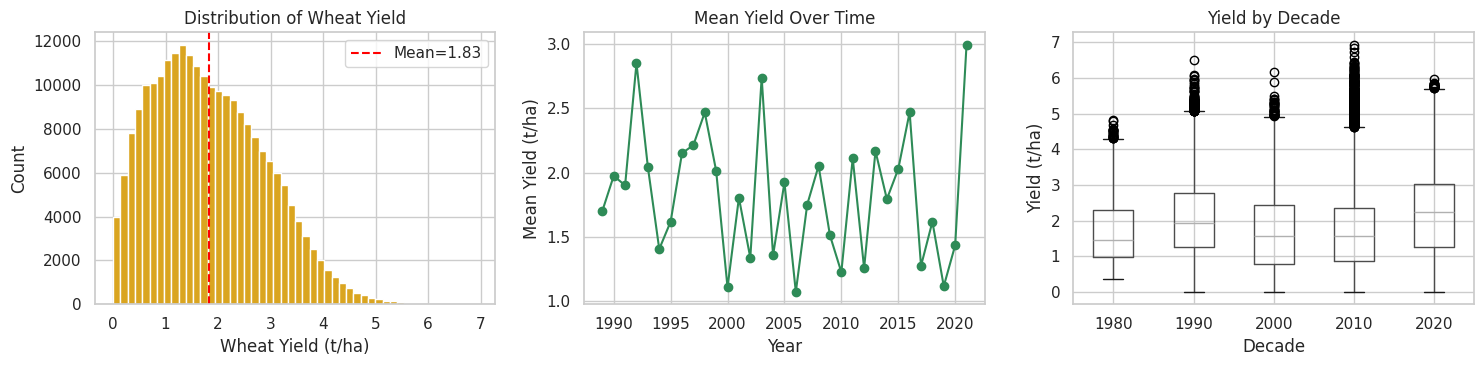

Yield stats: mean=1.83, std=1.06, min=0.00, max=6.94 t/ha


In [ ]:
# ──  Target variable: Wheat yield distribution ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(df['wheat_yield'], bins=50, color='goldenrod', edgecolor='white')
axes[0].set_xlabel('Wheat Yield (t/ha)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Wheat Yield')
axes[0].axvline(df['wheat_yield'].mean(), color='red', linestyle='--', label=f"Mean={df['wheat_yield'].mean():.2f}")
axes[0].legend()

# Yield by year
yr_mean = df.groupby('year')['wheat_yield'].mean()
axes[1].plot(yr_mean.index, yr_mean.values, marker='o', color='seagreen')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Mean Yield (t/ha)')
axes[1].set_title('Mean Yield Over Time')

# Boxplot by year decade
df['decade'] = (df['year'] // 10) * 10
df.boxplot(column='wheat_yield', by='decade', ax=axes[2])
axes[2].set_xlabel('Decade')
axes[2].set_ylabel('Yield (t/ha)')
axes[2].set_title('Yield by Decade')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f"Yield stats: mean={df['wheat_yield'].mean():.2f}, "
      f"std={df['wheat_yield'].std():.2f}, "
      f"min={df['wheat_yield'].min():.2f}, "
      f"max={df['wheat_yield'].max():.2f} t/ha")

### Question 2.2 — Interpreting the Yield Distribution
1. Is the yield distribution symmetric (normal) or skewed?
2. Do you notice any trend over time? What might cause it?
3. Are there years with unusually low yield? What events might explain this?

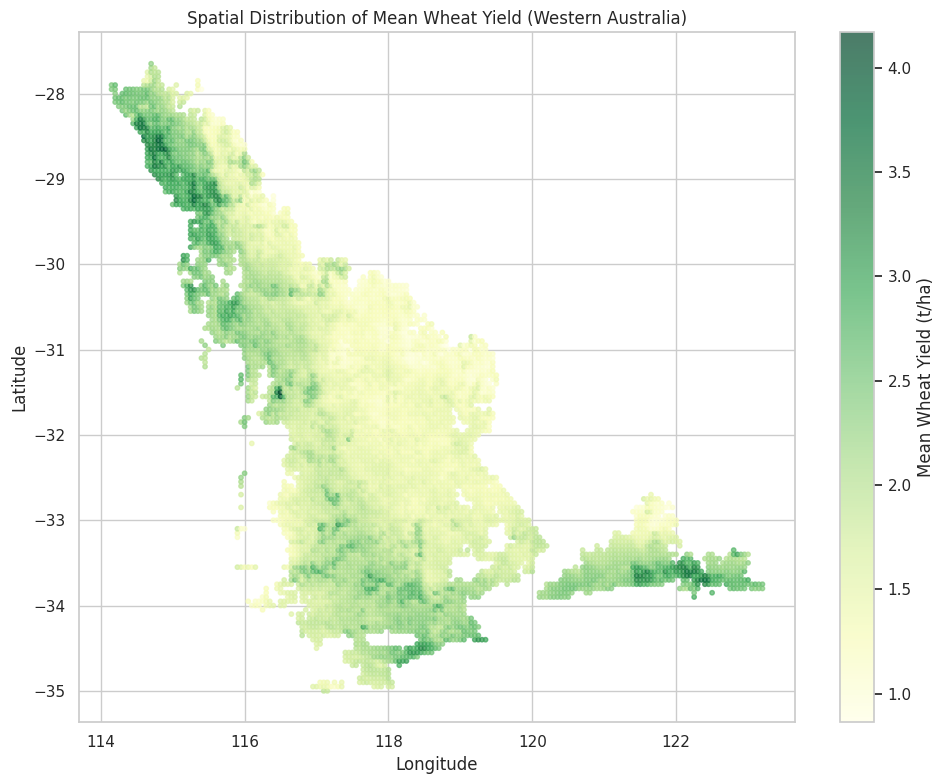

In [11]:
# ── 2.6 Spatial distribution of yield ─────────────────────────────
yield_by_cell = df.groupby(['lat', 'lon'])['wheat_yield'].mean().reset_index()

plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    yield_by_cell['lon'], yield_by_cell['lat'],
    c=yield_by_cell['wheat_yield'],
    cmap='YlGn', s=10, alpha=0.7
)
plt.colorbar(scatter, label='Mean Wheat Yield (t/ha)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Spatial Distribution of Mean Wheat Yield (Western Australia)')
plt.tight_layout()
plt.show()

In [13]:
# ── 2.7 Correlation analysis: which features relate to yield? ─────
# Select a manageable set of features for correlation
corr_features = (
    soil_cols[:5] +
    [c for c in df.columns if 'rain_sum' in c and ('_crop' in c or '_W3_' in c or '_W4_' in c)] +
    [c for c in df.columns if 'tmean' in c and ('_W3_' in c or '_W4_' in c)] +
    [c for c in df.columns if 'frost_days' in c] +
    [c for c in df.columns if 'heat_days' in c] +
    ['wheat_yield']
)
corr_features = [c for c in corr_features if c in df.columns]

corr_matrix = df[corr_features].corr()
yield_corr = corr_matrix['wheat_yield'].drop('wheat_yield').sort_values(key=abs, ascending=False)

print('Top 15 features correlated with wheat_yield:')
print(yield_corr.head(15).round(3))

Top 15 features correlated with wheat_yield:
rain_sum_W4_grainFill     0.556
tmean_W4_grainFill       -0.489
heat_days_crop           -0.445
heat_days_W4_grainFill   -0.417
heat_days_W5_matur       -0.415
rain_sum_crop             0.372
rain_sum_W3_preAnth       0.306
profile_depth_cm          0.267
tmean_W3_preAnth         -0.252
frost_days_W2_veg        -0.193
pawc_0_60_mm              0.177
frost_days_crop          -0.164
heat_days_W3_preAnth     -0.154
ph_0_30                   0.131
heat_days_W1_estab        0.129
Name: wheat_yield, dtype: float64


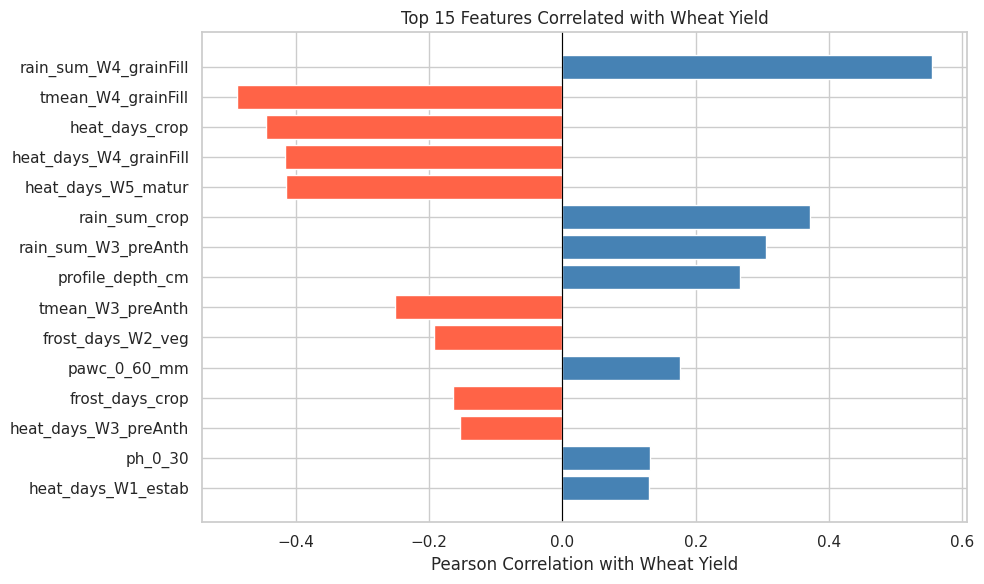

In [14]:
# ── 2.8 Visualise top correlations ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
top15 = yield_corr.head(15)
colors = ['steelblue' if v > 0 else 'tomato' for v in top15.values]
ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Wheat Yield')
ax.set_title('Top 15 Features Correlated with Wheat Yield')
plt.tight_layout()
plt.show()

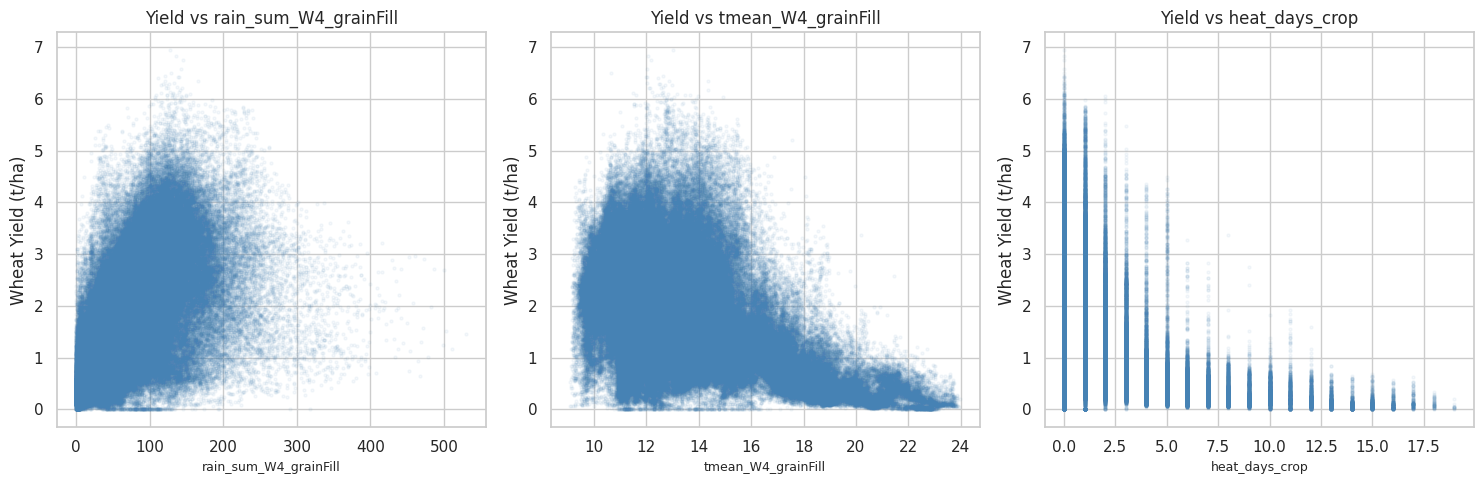

In [15]:
# ── 2.9 Scatter plots of top predictors vs yield ──────────────────
top3 = yield_corr.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, feat in zip(axes, top3):
    ax.scatter(df[feat], df['wheat_yield'],
               alpha=0.05, s=5, color='steelblue')
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel('Wheat Yield (t/ha)')
    ax.set_title(f'Yield vs {feat}')

plt.tight_layout()
plt.show()

### Question 2.3 — Feature Relationships
1. Which weather variable has the strongest positive correlation with yield? Does this make agronomic sense?
2. Which soil variable, if any, shows a relationship with yield?
3. Do the scatter plots show a **linear** relationship or something more complex? Why does this matter for the next model we build?

---
## Part 3: Multiple Linear Regression

**Linear regression** assumes that yield is a weighted sum of input features:  

$$\hat{y} = b_0 + b_1 x_1 + b_2 x_2 + \dots + b_n x_n$$

Where:
- $\hat{y}$ = predicted yield
- $x_i$ = input features (rain, temperature, soil, etc.)
- $b_i$ = coefficients 
- $b_0$ = intercept 

The model **learns** the best weights by minimising the sum of squared errors.

In [ ]:
# ── 3.1 Choose features for our model ─────────────────────────────
# We use a curated set that covers: soil, rainfall, temperature, stress

FEATURE_COLS = [
    # Soil
    'pawc_0_30_mm', 'pawc_0_60_mm', 'ph_0_30', 'profile_depth_cm',
    # Seasonal rainfall
    'rain_sum_W1_estab', 'rain_sum_W2_veg', 'rain_sum_W3_preAnth', 'rain_sum_W4_grainFill', 'rain_sum_crop',
    # Temperature
    'tmean_W3_preAnth', 'tmean_W4_grainFill', 'tmax_max_W4_grainFill',
    # Stress indicators
    'heat_days_W3_preAnth', 'heat_days_W4_grainFill',
    'frost_days_W1_estab', 'frost_days_W2_veg',
    'vpd_mean_W3_preAnth', 'vpd_mean_W4_grainFill',
    # Sowing date
    'sowing_doy',
]

TARGET_COL = 'wheat_yield'

# Keep only columns that exist in the dataset
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
print(f'Using {len(FEATURE_COLS)} features:')
for f in FEATURE_COLS:
    print(f'  • {f}')

In [ ]:
# ── 3.2 Prepare X (features) and y (target) ────────────────────────
data_model = df[FEATURE_COLS + [TARGET_COL]].dropna()
print(f'Rows after dropping NaN: {len(data_model):,}')

X = data_model[FEATURE_COLS].values
y = data_model[TARGET_COL].values

print(f'X shape: {X.shape}  (rows × features)')
print(f'y shape: {y.shape}  (target values)')

In [ ]:
# ── 3.3 Split data: Training vs Test ──────────────────────────────
# We hold out 20% of data for testing — the model NEVER sees this during training

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set:  {X_train.shape[0]:,} rows')
print(f'Test set:      {X_test.shape[0]:,} rows')
print()
print('💡 Why split the data?')
print('   Training = the model learns patterns from this data')
print('   Test = we simulate "new" data the model has never seen')
print('   This tells us how well the model will generalise in practice')

In [ ]:
# ── 3.4 Feature scaling (standardisation) ─────────────────────────
# Linear regression is sensitive to feature scale
# We transform each feature to have mean=0, std=1

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit ON train, transform train
X_test_sc  = scaler.transform(X_test)        # ONLY transform test (no fitting!)

print('Before scaling (first feature, first 5 rows):', X_train[:5, 0].round(2))
print('After scaling (first feature, first 5 rows): ', X_train_sc[:5, 0].round(2))
print()
print(' Critical rule: ALWAYS fit the scaler on TRAINING data only!')
print('   Using test data to fit the scaler would "leak" information into training.')

In [ ]:
# ── 3.5 Train the Linear Regression model ─────────────────────────
lr_model = LinearRegression()
lr_model.fit(X_train_sc, y_train)


print(f'\nIntercept (w₀): {lr_model.intercept_:.3f} t/ha')
print(f'\nFeature coefficients (w₁ … wₙ):')
coef_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'coefficient': lr_model.coef_
}).sort_values('coefficient', key=abs, ascending=False)
print(coef_df.to_string(index=False))

### Question 3.1 — Interpreting Coefficients
After scaling, coefficients show the **relative importance** of each feature.
1. Which features have the largest (absolute) coefficient? Are they what you expected?
2. A **positive** coefficient means: as the feature increases, yield ___?
3. A **negative** coefficient means: as the feature increases, yield ___?
4. Does the sign of each coefficient make agronomic sense?

In [ ]:
# ── 3.6 Make predictions ──────────────────────────────────────────
y_pred_train = lr_model.predict(X_train_sc)
y_pred_test  = lr_model.predict(X_test_sc)

print('First 5 predictions vs actual (test set):')
compare = pd.DataFrame({'Actual': y_test[:5], 'Predicted': y_pred_test[:5]})
compare['Error'] = compare['Predicted'] - compare['Actual']
print(compare.round(3))

---
## Part 4: Model Evaluation

We use three main metrics to evaluate regression models:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **RMSE** | $\sqrt{\frac{1}{n}\sum(\hat{y}-y)^2}$ | Average error in same units as yield (t/ha) |
| **MAE** | $\frac{1}{n}\sum|\hat{y}-y|$ | Average absolute error (less sensitive to outliers) |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Fraction of variance explained (1.0 = perfect, 0 = no better than mean) |

In [ ]:
# ── 4.1 Compute metrics ────────────────────────────────────────────
def evaluate(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'{label:15s}  RMSE={rmse:.3f} t/ha  MAE={mae:.3f} t/ha  R²={r2:.3f}')
    return {'rmse': rmse, 'mae': mae, 'r2': r2}

print('=== Model Performance ===')
train_metrics = evaluate(y_train, y_pred_train, 'Training')
test_metrics  = evaluate(y_test,  y_pred_test,  'Test')

print()
if train_metrics['r2'] - test_metrics['r2'] > 0.1:
    print('Train R² >> Test R²: possible overfitting!')
else:
    print('Train and Test performance are similar: good generalisation')

In [ ]:
# ── 4.2 Predicted vs Actual scatter plot ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (y_true, y_pred, label) in zip(axes, [
    (y_train, y_pred_train, 'Training'),
    (y_test,  y_pred_test,  'Test')
]):
    ax.scatter(y_true, y_pred, alpha=0.15, s=5, color='steelblue')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
    r2 = r2_score(y_true, y_pred)
    ax.set_xlabel('Actual Yield (t/ha)')
    ax.set_ylabel('Predicted Yield (t/ha)')
    ax.set_title(f'{label} Set  (R² = {r2:.3f})')
    ax.legend()

plt.suptitle('Linear Regression: Predicted vs Actual Wheat Yield', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ── 4.3 Residual analysis ─────────────────────────────────────────
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs predicted
axes[0].scatter(y_pred_test, residuals, alpha=0.15, s=5, color='coral')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_xlabel('Predicted Yield (t/ha)')
axes[0].set_ylabel('Residual (actual − predicted)')
axes[0].set_title('Residual Plot')

# Histogram of residuals
axes[1].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Residual (t/ha)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()

print(f'Mean residual: {residuals.mean():.4f} (should be ≈ 0)')
print(f'Std  residual: {residuals.std():.3f} t/ha')

### Question 4.1 — Residual Interpretation
A well-fitted linear regression should have residuals that:
1. Are centred around zero (no systematic bias)
2. Show no pattern when plotted against predicted values
3. Follow an approximately normal distribution

Look at the residual plots above:
- Do residuals show a **funnel shape** (wider at high/low yields)? What does this indicate?
- Are there clusters of large errors? When might this happen?

In [ ]:
# ── 4.4 Cross-validation: a more robust estimate of performance ───
# Instead of a single train/test split, use 5-fold CV

from sklearn.pipeline import Pipeline

# Build pipeline: scale then regress
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', LinearRegression())
])

# Drop NaN for cross-validation
data_cv = df[FEATURE_COLS + [TARGET_COL]].dropna()
X_cv = data_cv[FEATURE_COLS].values
y_cv = data_cv[TARGET_COL].values

cv_r2   = cross_val_score(pipeline, X_cv, y_cv, cv=5, scoring='r2')
cv_rmse = np.sqrt(-cross_val_score(pipeline, X_cv, y_cv, cv=5, scoring='neg_mean_squared_error'))

print('=== 5-Fold Cross-Validation ===')
print(f'R²  : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}  (per fold: {cv_r2.round(3)})')
print(f'RMSE: {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f} t/ha')
print()
print('💡 Cross-validation gives a more reliable performance estimate')
print('   than a single random split, especially with small datasets.')

In [ ]:
# ── 4.5 Feature importance via coefficient magnitude ──────────────
coef_df_sorted = coef_df.sort_values('coefficient')

fig, ax = plt.subplots(figsize=(8, 8))
colors = ['tomato' if v < 0 else 'steelblue' for v in coef_df_sorted['coefficient']]
ax.barh(coef_df_sorted['feature'], coef_df_sorted['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Standardised Coefficient')
ax.set_title('Linear Regression Feature Coefficients\n(after scaling — larger |coef| = more influential)')
plt.tight_layout()
plt.show()

---
## Part 4 (cont.): Limitations of Linear Regression

### Question 4.2 — When Does Linear Regression Fail?

Consider these **limitations** and check whether they apply to our data:

In [ ]:
# ── Limitation 1: Assumes LINEAR relationships ────────────────────
# Check if rain vs yield is really linear

rain_col = next((c for c in df.columns if 'rain_sum_crop' in c), None)
if rain_col:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Raw scatter
    axes[0].scatter(df[rain_col], df['wheat_yield'],
                    alpha=0.05, s=5, color='steelblue')
    axes[0].set_xlabel('Seasonal Rainfall (mm)')
    axes[0].set_ylabel('Wheat Yield (t/ha)')
    axes[0].set_title('Rain vs Yield — is this truly linear?')

    # Binned mean ± std
    bins = pd.cut(df[rain_col], bins=15)
    grp = df.groupby(bins)['wheat_yield']
    means = grp.mean()
    stds  = grp.std()
    xs    = [b.mid for b in means.index.categories]
    axes[1].errorbar(xs, means, yerr=stds, fmt='o-', capsize=4, color='darkgreen')
    axes[1].set_xlabel('Seasonal Rainfall (mm)')
    axes[1].set_ylabel('Mean Yield ± Std (t/ha)')
    axes[1].set_title('Binned Mean Yield by Rainfall')

    plt.tight_layout()
    plt.show()

In [ ]:
# ── Limitation 2: Does not capture interactions ───────────────────
# A hot+dry year is worse than hot alone OR dry alone
# Linear regression can't automatically model: heat × drought

heat_col = next((c for c in df.columns if 'heat_days_W4' in c), None)
vpd_col  = next((c for c in df.columns if 'vpd_mean_W4' in c or 'vpd_mean_W3' in c), None)

if heat_col and vpd_col:
    # Create interaction variable
    df['heat_x_vpd'] = df[heat_col] * df[vpd_col]
    corr_heat    = df[[heat_col, 'wheat_yield']].corr().iloc[0,1]
    corr_vpd     = df[[vpd_col, 'wheat_yield']].corr().iloc[0,1]
    corr_interact = df[['heat_x_vpd', 'wheat_yield']].corr().iloc[0,1]

    print(f'Correlation with yield:')
    print(f'  {heat_col:40s}: {corr_heat:.3f}')
    print(f'  {vpd_col:40s}: {corr_vpd:.3f}')
    print(f'  Interaction (heat × vpd):                {corr_interact:.3f}')
    print()
    print('💡 The interaction term can be MORE correlated with yield than')
    print('   either factor alone — but linear regression misses this automatically.')

In [ ]:
# ── Summary: Linear Regression Scorecard ─────────────────────────
print('=' * 55)
print('  LINEAR REGRESSION — SESSION 1 SUMMARY')
print('=' * 55)
print(f'  Features used : {len(FEATURE_COLS)}')
print(f'  Training R²   : {train_metrics["r2"]:.3f}')
print(f'  Test R²       : {test_metrics["r2"]:.3f}')
print(f'  Test RMSE     : {test_metrics["rmse"]:.3f} t/ha')
print(f'  Test MAE      : {test_metrics["mae"]:.3f} t/ha')
print()


---
##  Session 1 — Take-Home Exercises

**Exercise A:** Add 5 more features from the monthly rainfall columns to the model. Does R² improve?

**Exercise B:** Try Ridge Regression (`from sklearn.linear_model import Ridge`) instead of plain linear regression. Ridge adds a penalty to prevent large coefficients. Does it perform differently? Why might it help?

**Exercise C:** Split the data by **year** instead of randomly (train on 1989–2010, test on 2011–2021). How does performance change? What does this tell you about predicting future seasons?

**Exercise D:** Look at the year with the worst mean yield in the dataset. Which climate features had extreme values that year? Can you see why yield was low?

---
